# Simulaciones relacionadas con la entropía

## Evolución temporal de la entropía en cada celda

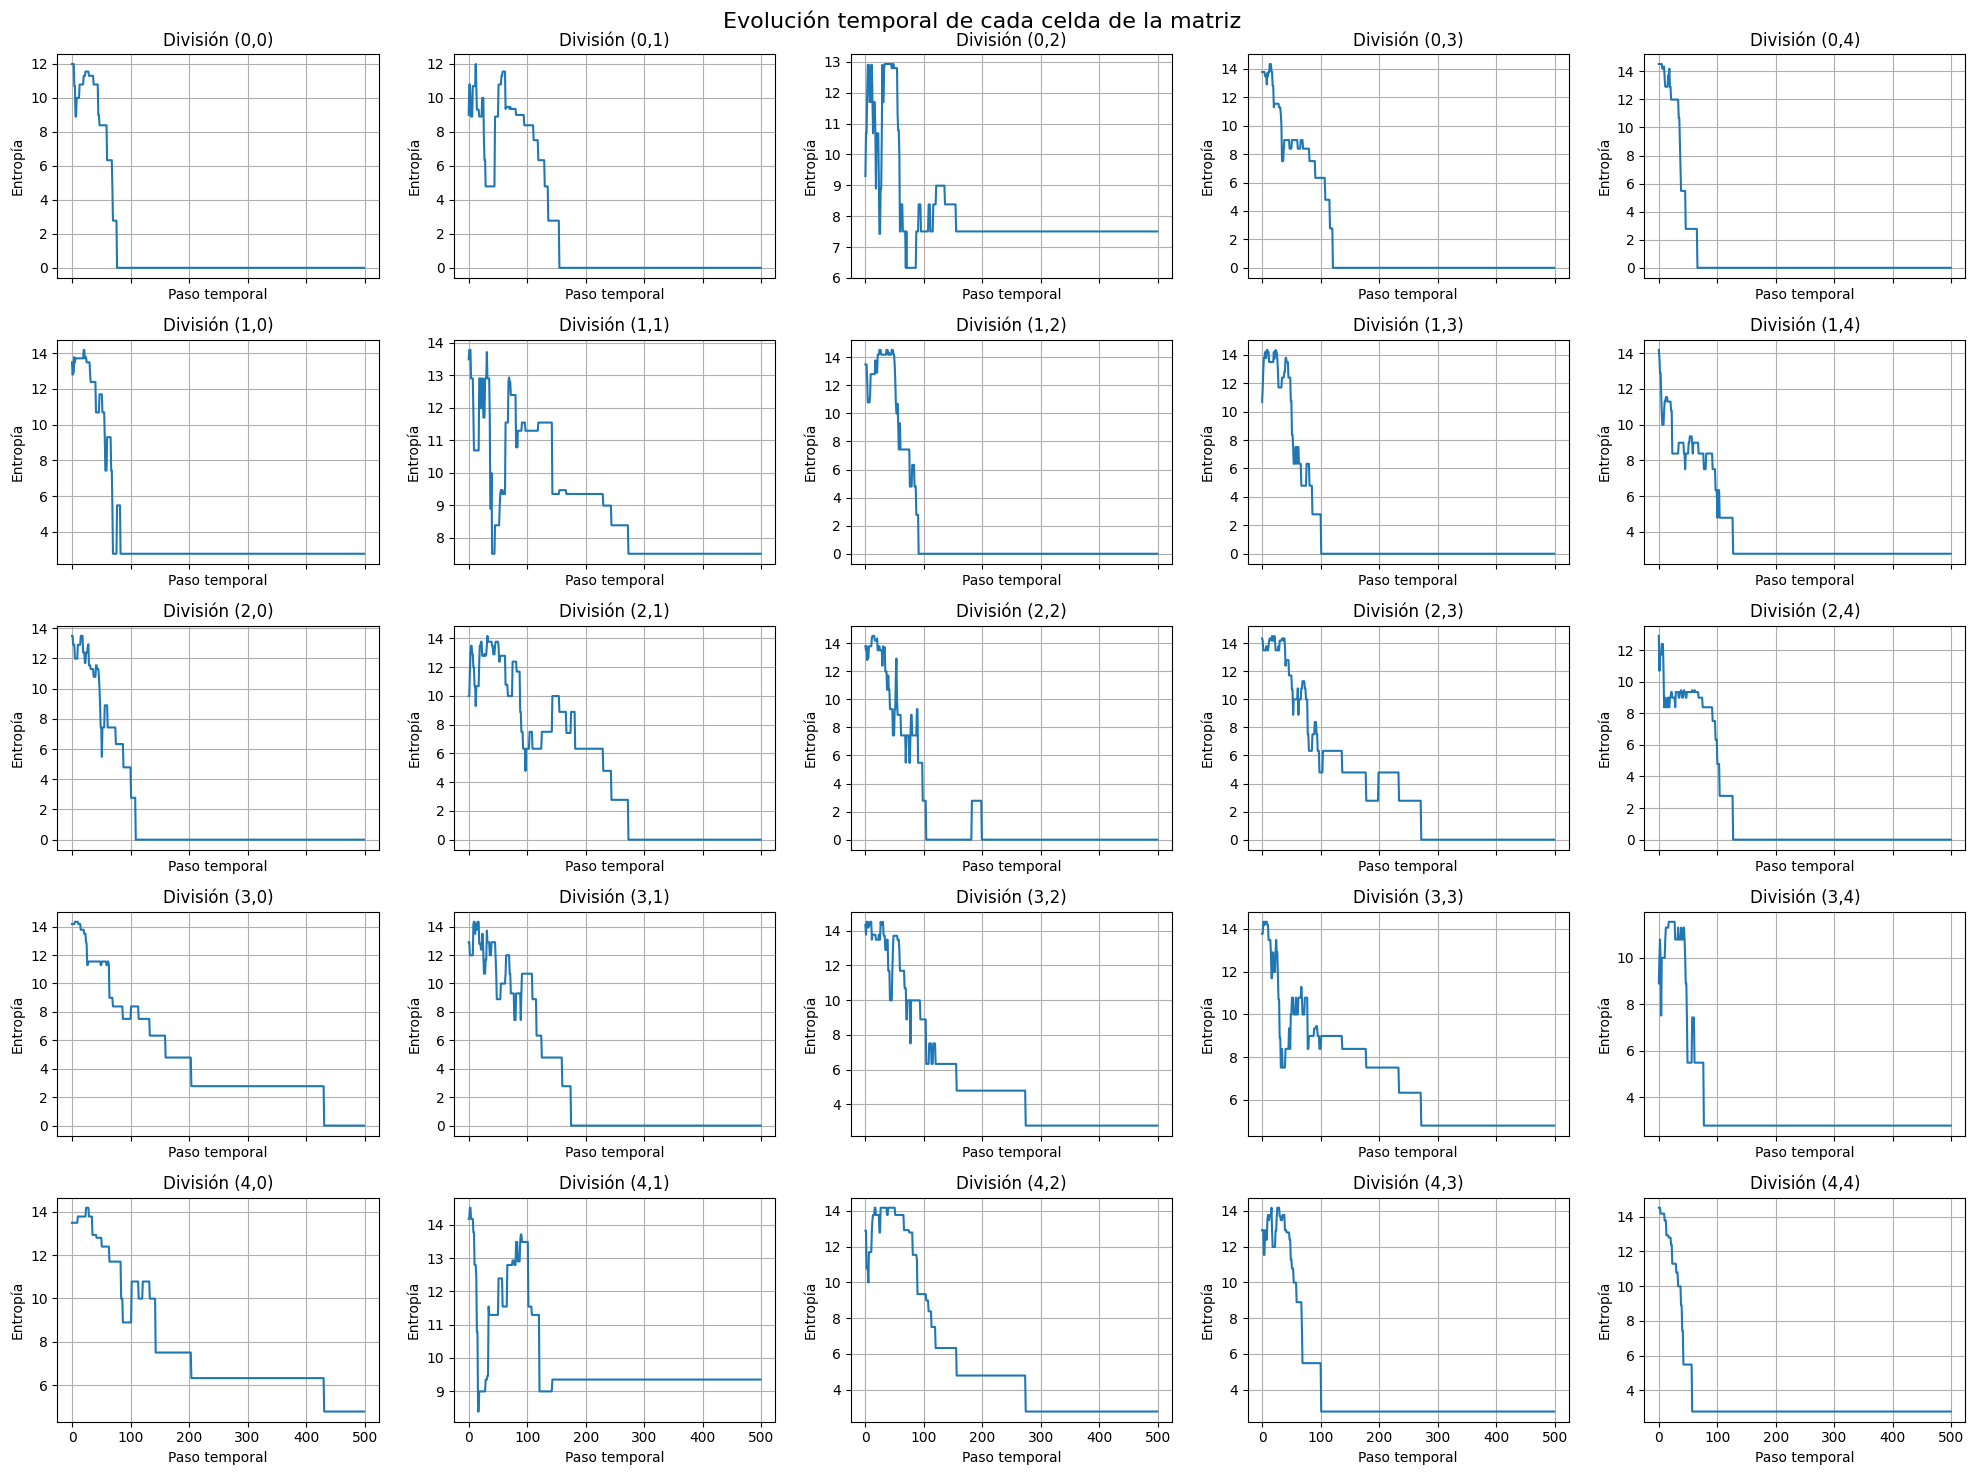

In [1]:
### CÓDIGO PARA ENTROPÍA SIN PROMEDIAR #########################

import numpy as np
import matplotlib.pyplot as plt

# ===== LEER EL FICHERO =====
with open("entropy_subdivisions.txt", "r", encoding="utf-8") as f:
    texto = f.read().strip()


# ===== SEPARAR LOS PASOS TEMPORALES =====
# Cada bloque separado por una línea en blanco es una matriz en un instante de tiempo
bloques = texto.split("\n\n")


matrices = []

for bloque in bloques:
    lineas = bloque.strip().split("\n")
    matriz = []

    for linea in lineas:
        fila = list(map(float, linea.split()))
        matriz.append(fila)

    matrices.append(matriz)

# Convertimos a array de numpy
datos = np.array(matrices)

# dimensiones: (tiempo, filas, columnas)
num_tiempos = datos.shape[0]
num_filas = datos.shape[1]
num_columnas = datos.shape[2]

# Vector temporal
t = np.arange(num_tiempos)

# ===== HACER LA FIGURA =====
fig, axes = plt.subplots(num_filas, num_columnas, figsize=(4*num_columnas, 3*num_filas), sharex=True)

# Por si alguna vez la matriz fuese de 1 fila o 1 columna
if num_filas == 1 and num_columnas == 1:
    axes = np.array([[axes]])
elif num_filas == 1:
    axes = axes[np.newaxis, :]
elif num_columnas == 1:
    axes = axes[:, np.newaxis]

# ===== PLOT DE CADA CELDA =====
for i in range(num_filas):
    for j in range(num_columnas):
        axes[i, j].plot(t, datos[:, i, j])
        axes[i, j].set_title(f"División ({i},{j})")
        axes[i, j].set_xlabel("Paso temporal")
        axes[i, j].set_ylabel("Entropía")
        axes[i, j].grid(True)

fig.suptitle("Evolución temporal de cada celda de la matriz", fontsize=16)
fig.tight_layout()

# Guardar imagen
plt.savefig("plots/evolucion_entropia_celdas.png", dpi=200, bbox_inches="tight")

# Mostrar
plt.show()

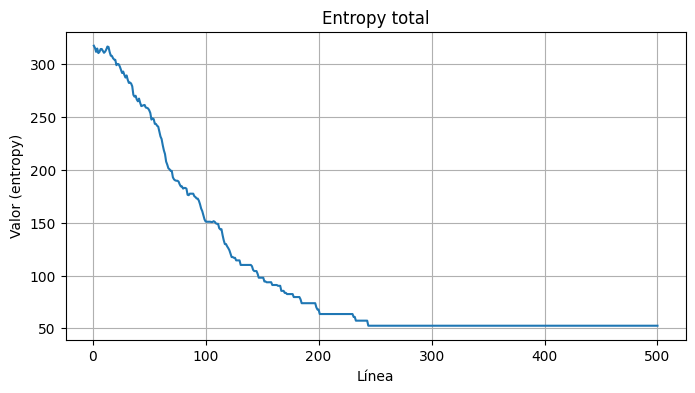

In [10]:
### CÓDIGO PARA ENTROPÍA TOTAL #################

import numpy as np
import matplotlib.pyplot as plt

path = "entropy_total.txt"
vals = []
with open(path, 'r', encoding='utf-8') as f:
    for line in f:
        s = line.strip()
        if not s or s.startswith('#'):
            continue
        token = s.split()[0].replace(',', '.')
        try:
            vals.append(float(token))
        except ValueError:
            pass

y = np.array(vals)
x = np.arange(1, len(y)+1)

plt.figure(figsize=(8,4))
plt.plot(x, y)
plt.xlabel('Línea')
plt.ylabel('Valor (entropy)')
plt.title('Entropy total')
plt.grid(True)
plt.savefig("plots/evolucion_entropia_total.png")
plt.show()

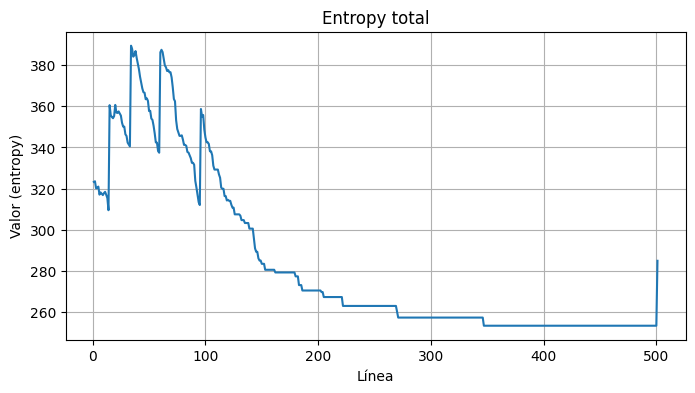

In [11]:
### CÓDIGO PARA ENTROPÍA TOTAL CON EL DEMONIO #################

import numpy as np
import matplotlib.pyplot as plt

path = "entropy_demon.txt"
vals = []
with open(path, 'r', encoding='utf-8') as f:
    for line in f:
        s = line.strip()
        if not s or s.startswith('#'):
            continue
        token = s.split()[0].replace(',', '.')
        try:
            vals.append(float(token))
        except ValueError:
            pass

y = np.array(vals)
x = np.arange(1, len(y)+1)

plt.figure(figsize=(8,4))
plt.plot(x, y)
plt.xlabel('Línea')
plt.ylabel('Valor (entropy)')
plt.title('Entropy total')
plt.grid(True)
plt.savefig("plots/evolucion_entropia_DEMONIO.png")
plt.show()